In [64]:
import numpy as np
import pandas as pd
from bitalg.tests.test2 import Test
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer
from functools import cmp_to_key


In [65]:
def det(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return a[0]*b[1]+b[0]*c[1] +c[0]*a[1] - b[1]*c[0]-c[1]*a[0]-a[1]*b[0]

In [66]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result

In [67]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [68]:
EPS = 10 **(-10)
def orient(a,b,c):
    r = det(a,b,c)
    if abs(r) < EPS:
        return 0
    elif r >0: return 1 
    else: return -1

In [69]:
def find_extreme_x_points(Q):
    min_x_point = min(Q, key=lambda p: (p[0], p[1]))
    max_x_point = max(Q, key=lambda p: (p[0], p[1]))
    return min_x_point, max_x_point

In [70]:
#wysokość jest proporcjonalna do pola równologłoboku
def P(p1, p2 ,p):
    return det(p1,p2,p)

In [71]:
def divide(Q, p1,p2):
    on_left = []
    on_right = []
    for point in Q:
        if orient(p1,p2,point) ==1:
            on_left.append(point)
        elif orient(p1, p2, point) == -1:
            on_right.append(point)
    return on_left, on_right

In [72]:
def farthest_point(S, p1,p2):
    max_P = 0
    res = -1
    for p in S:
        if P(p1,p2, p) > max_P:
            res = p
            max_P = P(p1,p2,p)
    return res

In [73]:

def compare(p0,p1,p2):
    r = orient(p0,p1,p2)
    if r==-1:
            return 1
    elif r==1: return -1
    else: return 0

In [74]:
def min_y(Q):
    n = len(Q)
    mini = Q[0]
    for i in range(n):
        if Q[i][1] < mini[1] or (Q[i][1] == mini[1] and Q[i][0] < mini[0]):
            mini=Q[i]
    return mini

In [75]:



def quick_hull(points):
    p_min, p_max = find_extreme_x_points(points)
    CH = [p_min, p_max]
    def find_hull(S, A,B):
        nonlocal points, CH
        if not S:
            return
        C = farthest_point(S,A,B)
        CH.append(C)
        left_to_ac, _ = divide(S,A,C)
        left_to_cb, _ = divide(S,C,B)
        find_hull(left_to_ac,A,C)
        find_hull(left_to_cb,C,B)
    on_left, on_right = divide(points, p_min, p_max)
    find_hull(on_left, p_min, p_max) 
    find_hull(on_right, p_max, p_min)
    p0 = min_y(CH)
    CH.remove(p0)
    print(CH)
    CH.sort(key=cmp_to_key(lambda a, b: compare(p0, a, b)))
    CH.append(p0)
    return CH
    

[(45.45111274995336, 11.71926713492173), (97.94431915827599, 68.15673563614196), (59.55850633686863, 3.3176063923080257), (4.1437311021970675, 61.633859656287356), (33.17820502669212, 27.163667814340876), (87.33782659301484, 67.34449691933855), (19.85721286831491, 90.41523640208833), (5.780761933035117, 70.89595894651963), (3.7882294248585024, 79.86653160821241), (98.18670090525269, 99.96539813252102), (38.86896291497759, 0.7862771285986336), (35.32659683495542, 16.188924036317065), (28.009830834803306, 34.65430730137016), (8.676823665845635, 76.19823469190634), (74.11611711033372, 93.86127686833719), (16.01459627938292, 45.878649749734144), (54.94793010855563, 89.72790034260953), (54.73138643002316, 70.02904478349603), (7.062162464048793, 22.765244828723585), (32.12901641763071, 3.3200399599702335)]
[(3.7882294248585024, 79.86653160821241), (98.18670090525269, 99.96539813252102), (19.85721286831491, 90.41523640208833), (59.55850633686863, 3.3176063923080257), (97.94431915827599, 68.15

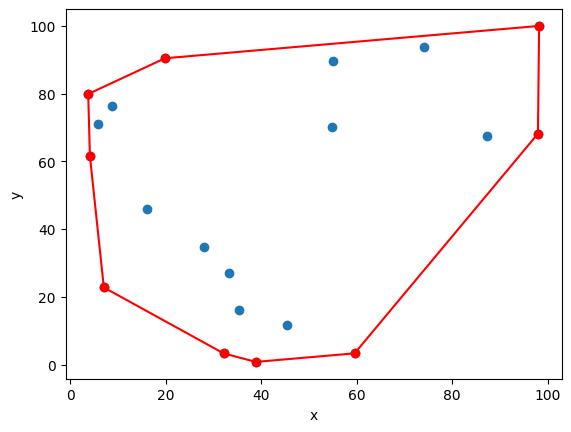

In [76]:

test = generate_uniform_points(0,100,20)
print(test)
v = Visualizer()
v.add_point(test)
res = quick_hull(test)
print(res)
display_convex_hull(v, test, res)

In [77]:

def quick_hull_vis(points):
    vis = Visualizer()
    vis.add_point(points)
    p_min, p_max = find_extreme_x_points(points)
    CH = [p_min, p_max]
    def find_hull(S, A,B, last_line):
        nonlocal points, CH, vis
        if not S:
            return
        
        C = farthest_point(S,A,B)
        CH.append(C)
        vis.add_point(C, color="red")
        ac_line = vis.add_line_segment([A, C], color="red")
        cb_line = vis.add_line_segment([C, B], color="red")
        
        left_to_ac, _ = divide(S,A,C)
        left_to_cb, _ = divide(S,C,B)
        if last_line is not None:
            vis.remove_figure(last_line)
            
        find_hull(left_to_ac,A,C, ac_line)
        find_hull(left_to_cb,C,B, cb_line)
    vis.add_point(CH, color="red")
    on_left, on_right = divide(points, p_min, p_max)
    line = vis.add_line_segment([p_min, p_max], color="red")
    find_hull(on_left, p_min, p_max, None) 
    find_hull(on_right, p_max, p_min, line)
    return vis

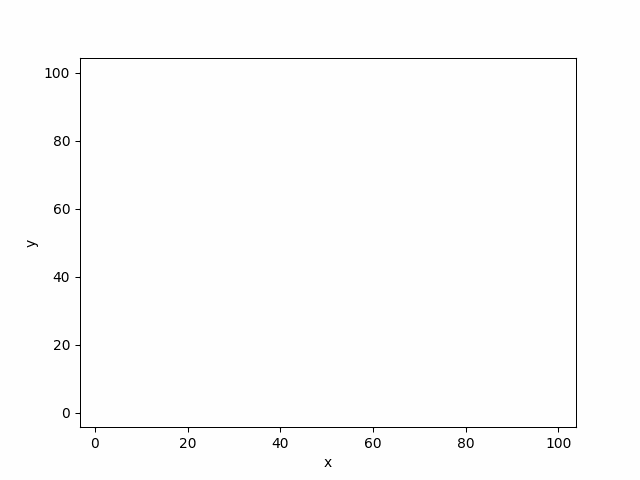

In [78]:
test = generate_uniform_points(0,100,100)
vis = quick_hull_vis(test)
vis.show_gif(interval=500)